In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path


In [5]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        json_data = df_webgazer["webgazer_data"].iloc[row].replace("'", "\"")
        data_list = json.loads(json_data)
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [6]:
def generate_chinrest_dataframe(df, i):
    df_chin = df[~df["view_dist_mm"].isna()][["view_dist_mm", "trial_index", "rt"]]
    df_chin["experiment"] = i
    return df_chin

In [7]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data/all-exp-separados").glob("*.csv")
dfs = []
dfs_chin = []
i = 0
for file in files:
    if "dist" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        dfs.append(df_tmp)
        df_virtual_chin_tmp = generate_chinrest_dataframe(df, i)
        dfs_chin.append(df_virtual_chin_tmp)
        #print(df_virtual_chin_tmp)
        i+=1

df_webgazer = pd.concat(dfs)
df_virtual_chin = pd.concat(dfs_chin)
print(len(df_webgazer))

data/all-exp-separados/dataframe_dist_20.csv
5479
data/all-exp-separados/dataframe_dist_21.csv
7354
data/all-exp-separados/dataframe_dist_23.csv
7594
data/all-exp-separados/dataframe_dist_9.csv
5346
data/all-exp-separados/dataframe_dist_8.csv
790
data/all-exp-separados/dataframe_dist_22.csv
6215
data/all-exp-separados/dataframe_dist_25.csv
3753
data/all-exp-separados/dataframe_dist_19.csv
2980
data/all-exp-separados/dataframe_dist_18.csv
8658
data/all-exp-separados/dataframe_dist_24.csv
5460
data/all-exp-separados/dataframe_dist_15.csv
4815
data/all-exp-separados/dataframe_dist_3.csv
5705
data/all-exp-separados/dataframe_dist_2.csv
8487
data/all-exp-separados/dataframe_dist_14.csv
4971
data/all-exp-separados/dataframe_dist_16.csv
4242
data/all-exp-separados/dataframe_dist_1.csv
4136
data/all-exp-separados/dataframe_dist_17.csv
993
data/all-exp-separados/dataframe_dist_13.csv
6460
data/all-exp-separados/dataframe_dist_5.csv
679
data/all-exp-separados/dataframe_dist_4.csv
5557
data/all-e

In [12]:
df_webgazer

,x,y,t,importantKeypoints,dz,trial
0,0,0,5.0,"{'noseX': 320.15, 'noseY': 267.38, 'topY': 168...",52.28,1
1,0,0,39.0,"{'noseX': 320.26, 'noseY': 267.07, 'topY': 168...",52.91,1
2,0,0,72.0,"{'noseX': 320.47, 'noseY': 267.39, 'topY': 168...",52.36,1
3,0,0,111.0,"{'noseX': 320.62, 'noseY': 267.31, 'topY': 168...",52.10,1
4,0,0,140.0,"{'noseX': 320.62, 'noseY': 267.16, 'topY': 168...",54.72,1
...,...,...,...,...,...,...
770,0,0,26185.0,"{'noseX': 356.44, 'noseY': 267.37, 'topY': 172...",46.76,3
771,0,0,26218.0,"{'noseX': 355.97, 'noseY': 267.1, 'topY': 170....",47.23,3
772,0,0,26253.0,"{'noseX': 356.6, 'noseY': 266.55, 'topY': 170....",47.62,3
773,0,0,26286.0,"{'noseX': 356.33, 'noseY': 266.71, 'topY': 170...",47.40,3


In [8]:
df_virtual_chin.head()

,view_dist_mm,trial_index,rt,experiment
3,480.92,3,102850.0,0
4,464.58,4,56612.0,0
5,462.72,5,26810.0,0
3,668.07,3,115500.0,1
4,676.17,4,65873.0,1


In [9]:
df_virtual_chin.groupby("experiment").mean()

,view_dist_mm,trial_index,rt
experiment,,,
0,469.406667,4.0,62090.666667
1,674.530000,4.0,83350.000000
2,590.290000,4.0,86109.666667
3,563.016667,4.0,83385.000000
4,575.916667,4.0,134974.333333
5,520.226667,4.0,71921.666667
6,609.416667,4.0,42522.000000
7,582.196667,4.0,58023.000000
8,522.560000,4.0,105125.666667


In [38]:
files = Path("./data/all-exp-separados").glob("*.csv")

for file in files:
    if "dist" in str(file):
        df = pd.read_csv(file)
        df_webgazer = generate_webgazer_dataframe(df)

        df_virtual_chin = df[~df["view_dist_mm"].isna()]
        df_virtual_chin.loc[:, ["view_dist_centimeters"]] = (
            df[~df["view_dist_mm"].isna()]["view_dist_mm"] / 10
        )
        (
            df_virtual_chin["rt"].reset_index(drop=True),
            df_webgazer.groupby("trial")["t"].max(),
        )
df_virtual_chin["rt"].head()



3    95647.0
4    42152.0
5    26349.0
Name: rt, dtype: float64

In [48]:
files = Path("./data/all-exp-separados").glob("*.csv")

for file in files:
  if "_8" not in str(file):
    if "dist" in str(file):
        df = pd.read_csv(file)
        df_webgazer = generate_webgazer_dataframe(df)

        df_virtual_chin = df[~df["view_dist_mm"].isna()].copy()
        df_virtual_chin.loc[:, ["view_dist_centimeters"]] = (
            df[~df["view_dist_mm"].isna()]["view_dist_mm"] / 10
        )
        (
            df_virtual_chin["rt"].reset_index(drop=True),
            df_webgazer.groupby("trial")["t"].max(),
        )
df_webgazer

,x,y,t,importantKeypoints,dz,trial
0,0,0,5,"{'noseX': 320.15, 'noseY': 267.38, 'topY': 168...",52.28,1
1,0,0,39,"{'noseX': 320.26, 'noseY': 267.07, 'topY': 168...",52.91,1
2,0,0,72,"{'noseX': 320.47, 'noseY': 267.39, 'topY': 168...",52.36,1
3,0,0,111,"{'noseX': 320.62, 'noseY': 267.31, 'topY': 168...",52.10,1
4,0,0,140,"{'noseX': 320.62, 'noseY': 267.16, 'topY': 168...",54.72,1
...,...,...,...,...,...,...
770,0,0,26185,"{'noseX': 356.44, 'noseY': 267.37, 'topY': 172...",46.76,3
771,0,0,26218,"{'noseX': 355.97, 'noseY': 267.1, 'topY': 170....",47.23,3
772,0,0,26253,"{'noseX': 356.6, 'noseY': 266.55, 'topY': 170....",47.62,3
773,0,0,26286,"{'noseX': 356.33, 'noseY': 266.71, 'topY': 170...",47.40,3


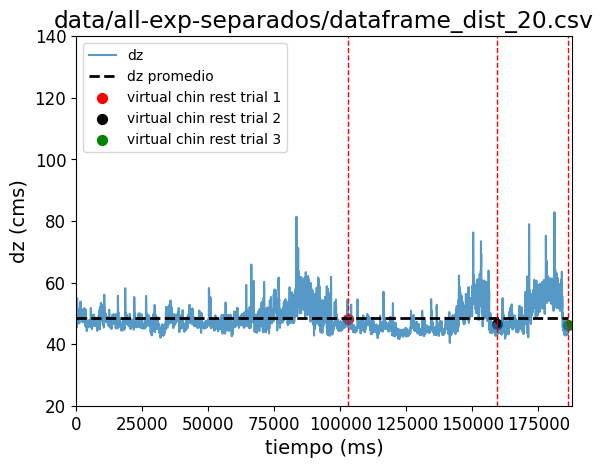

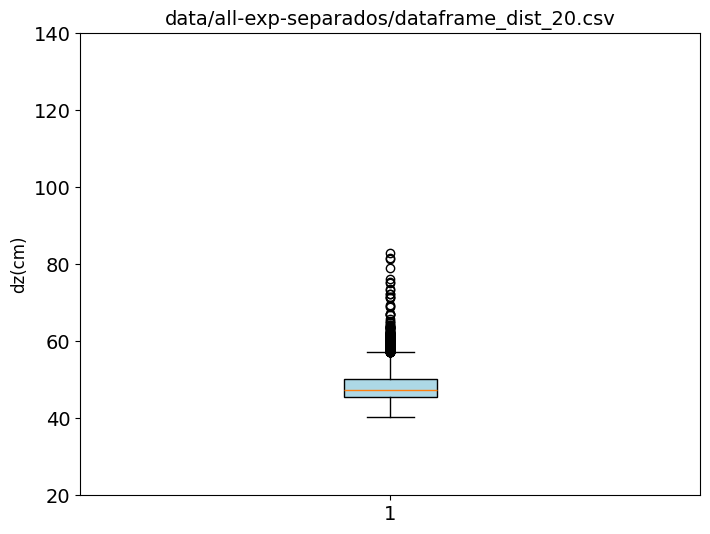

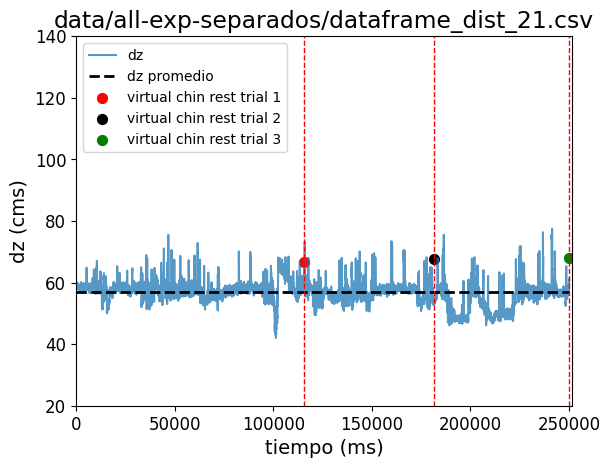

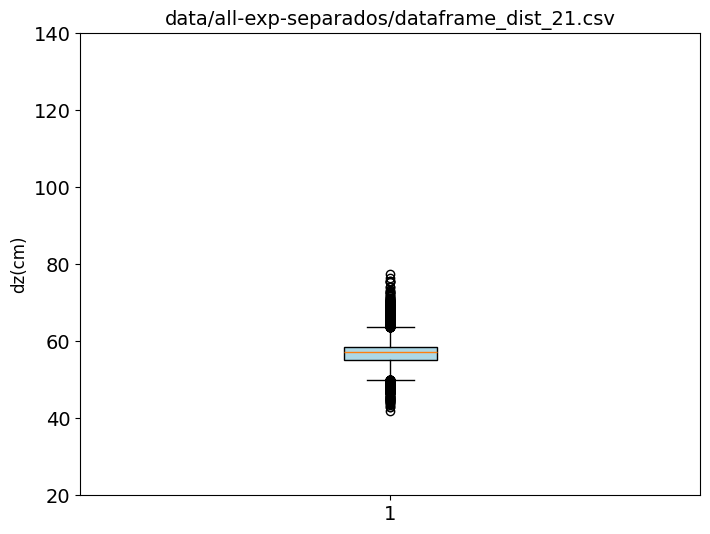

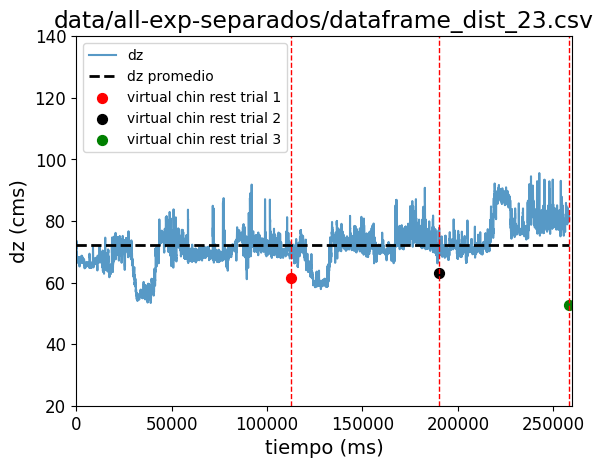

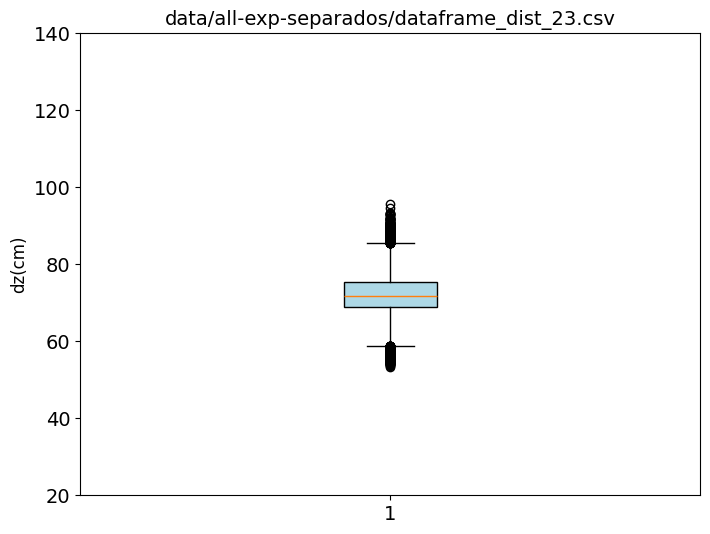

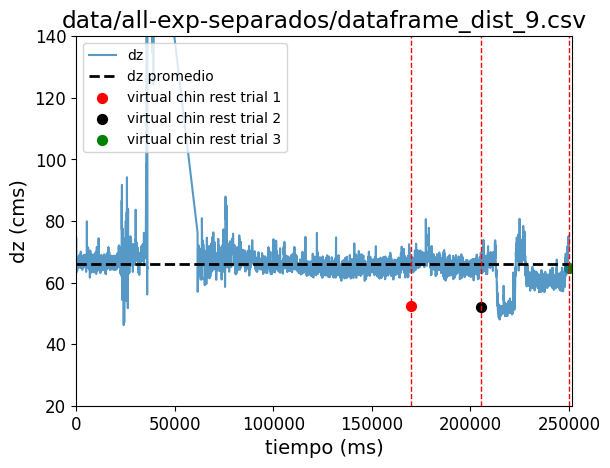

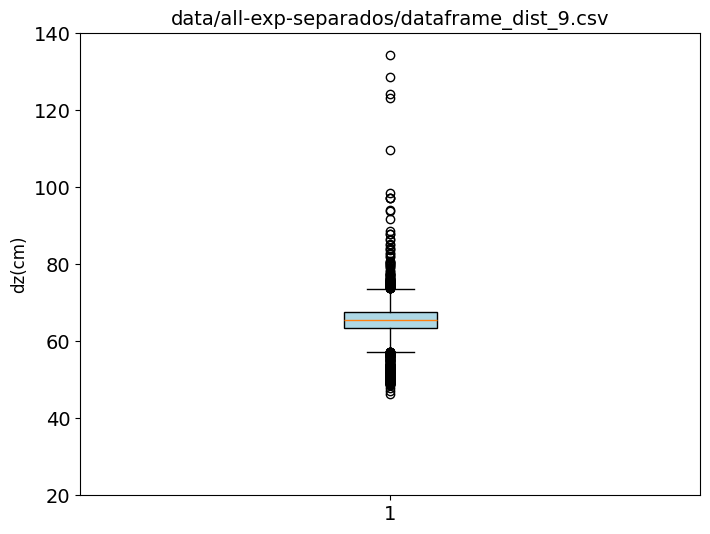

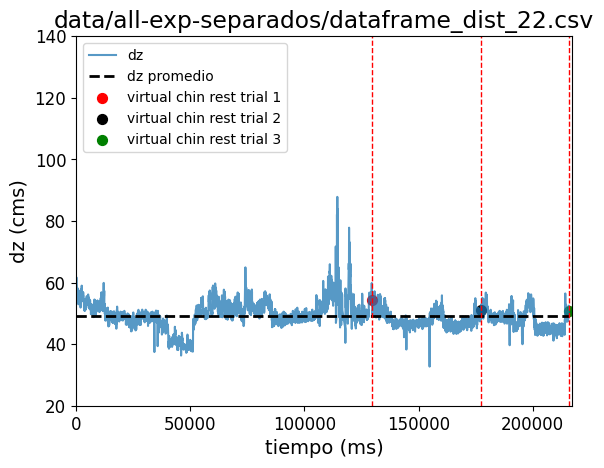

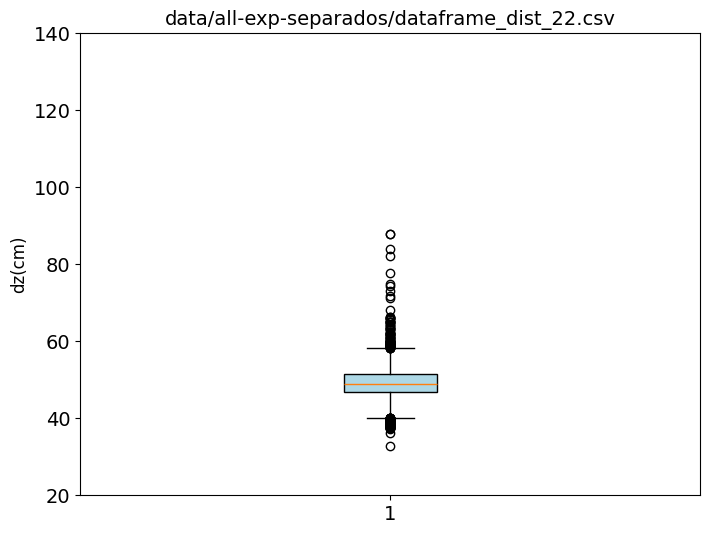

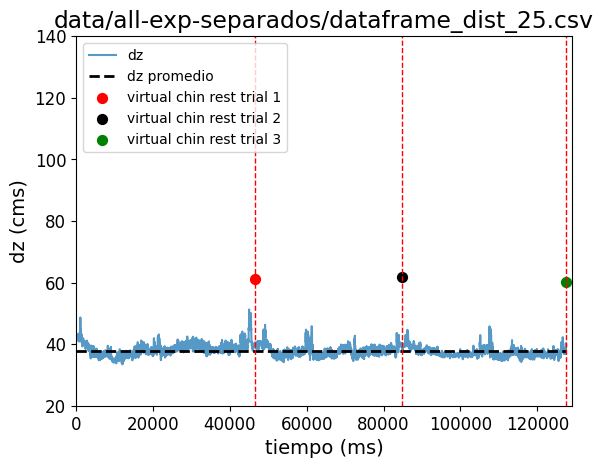

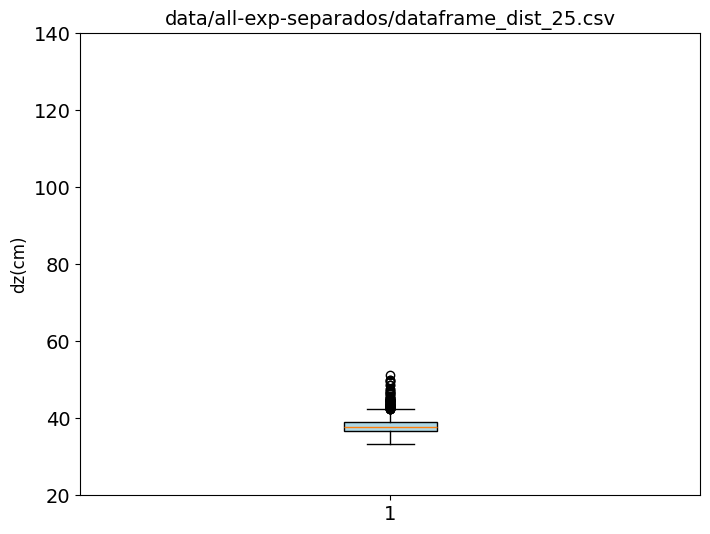

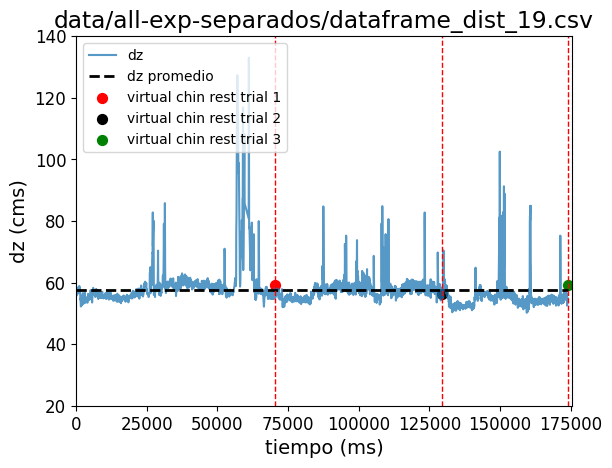

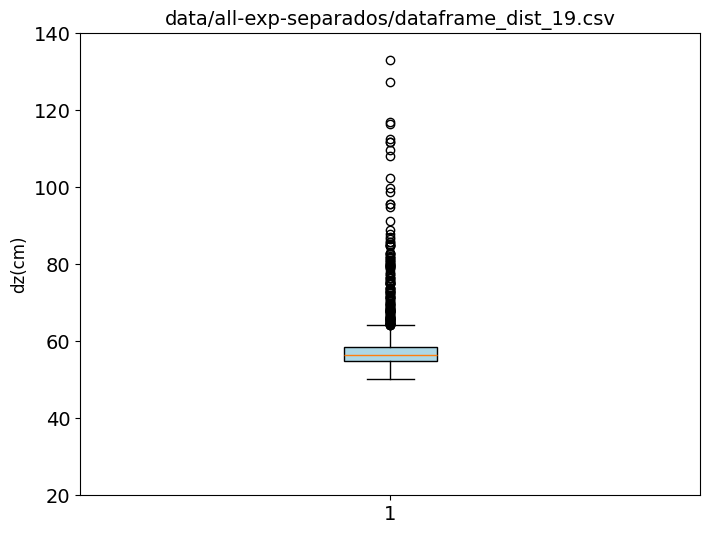

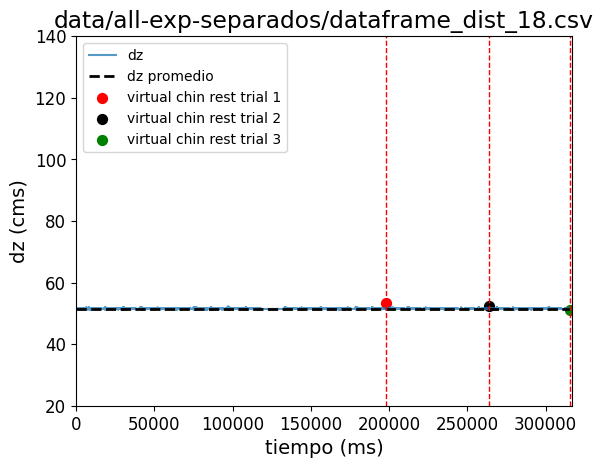

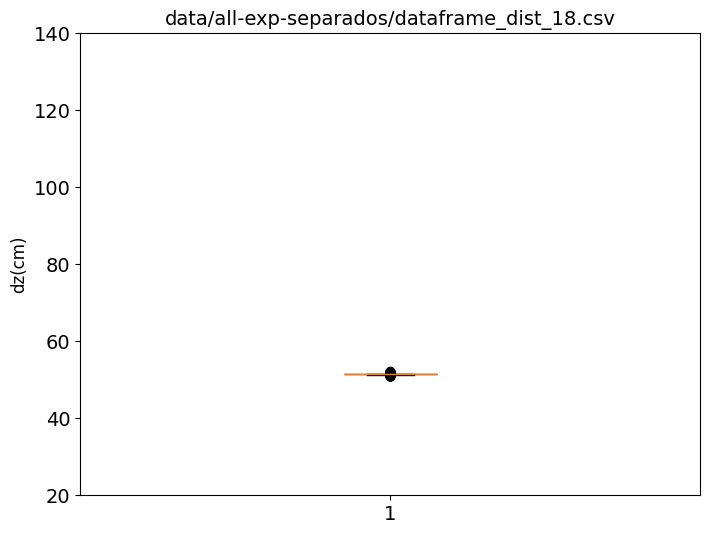

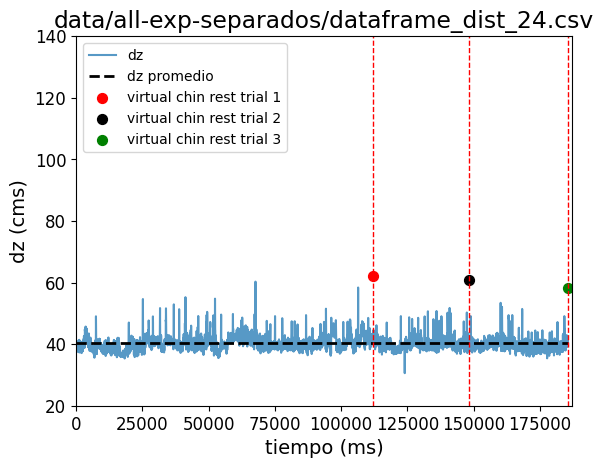

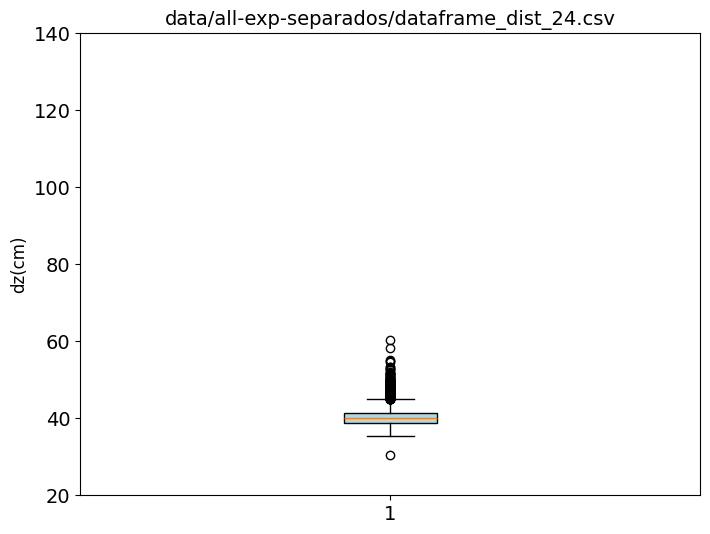

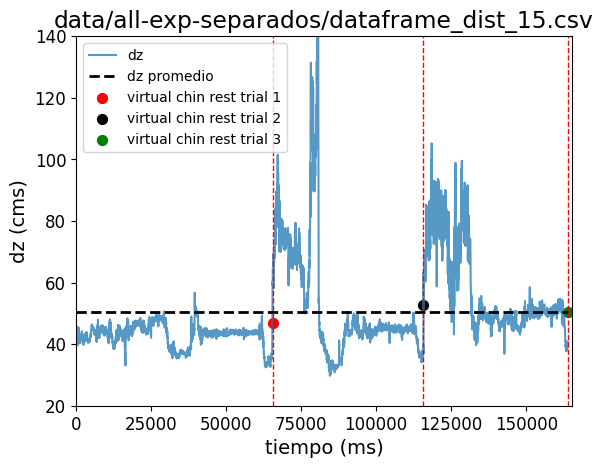

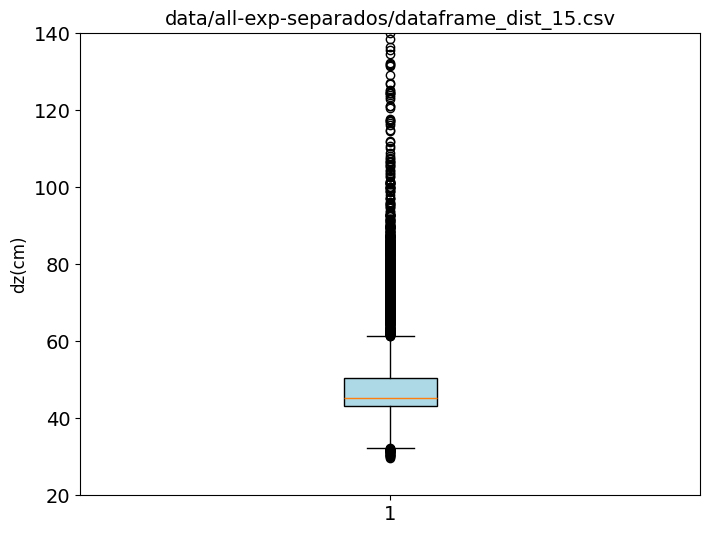

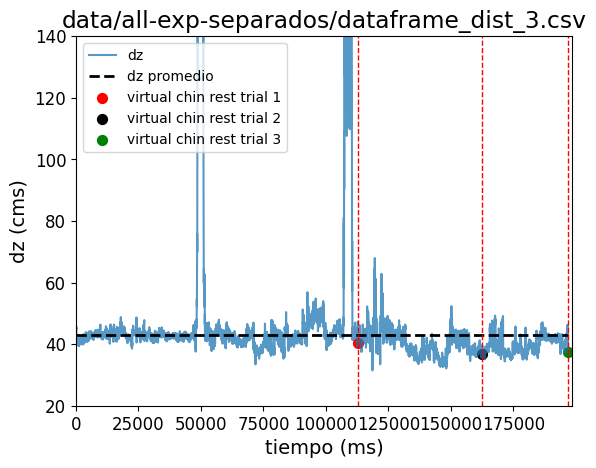

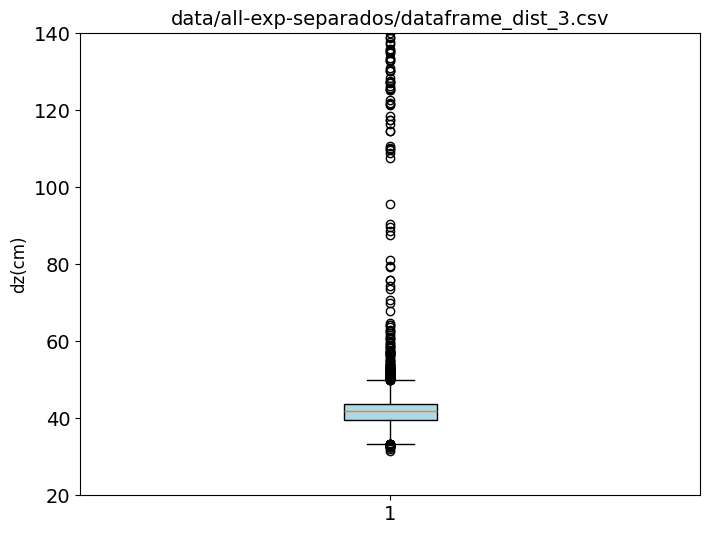

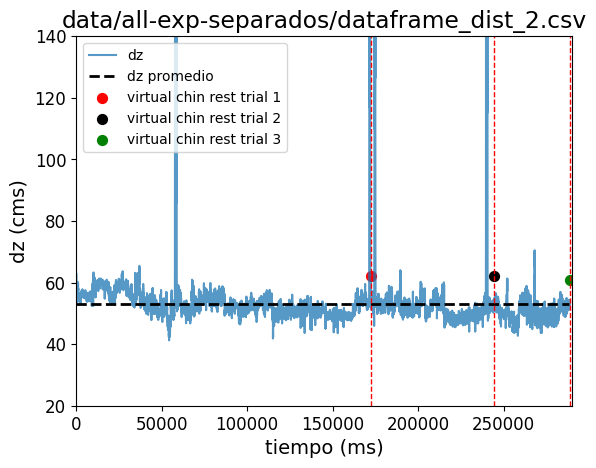

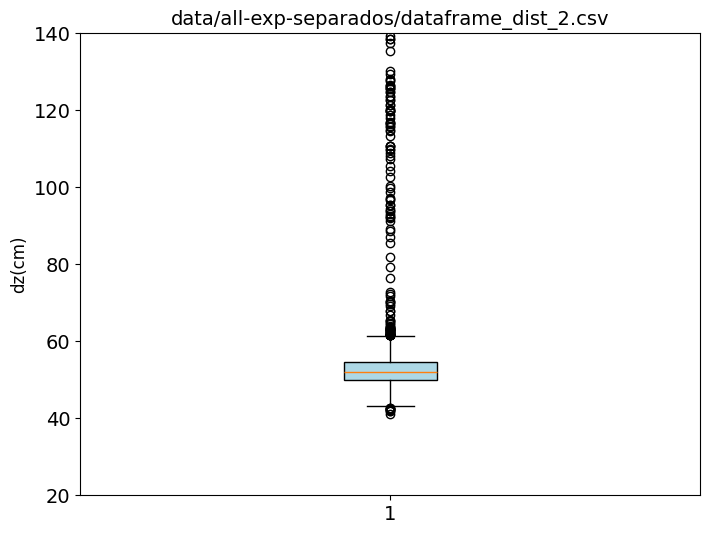

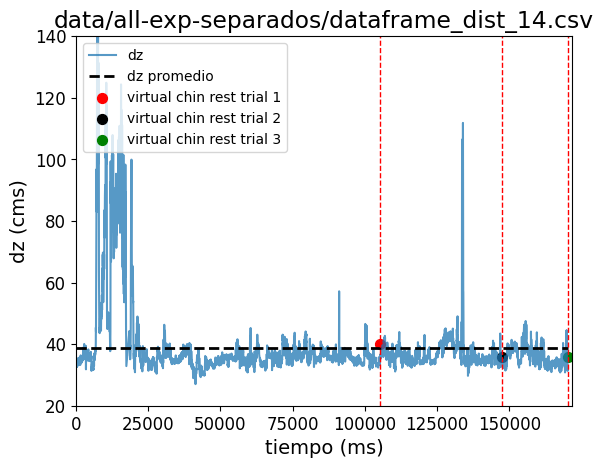

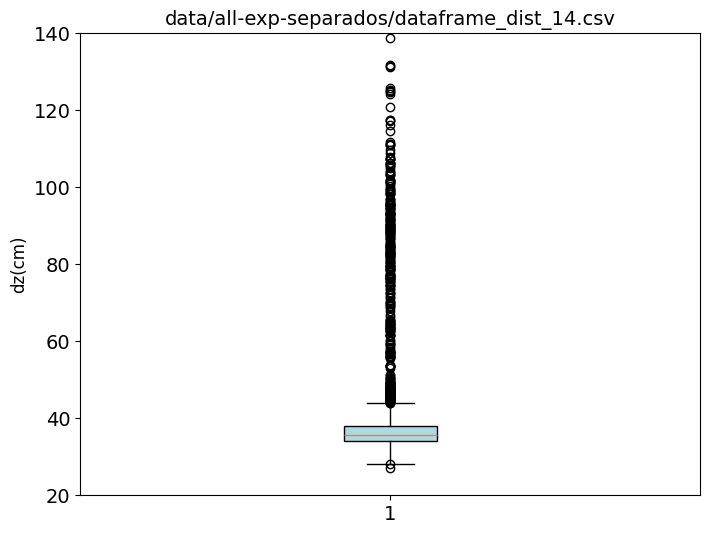

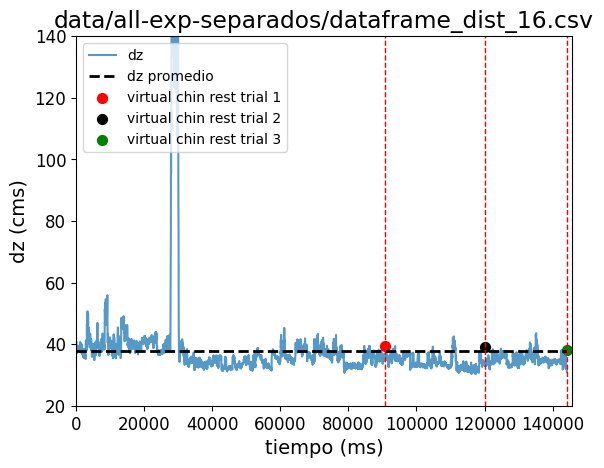

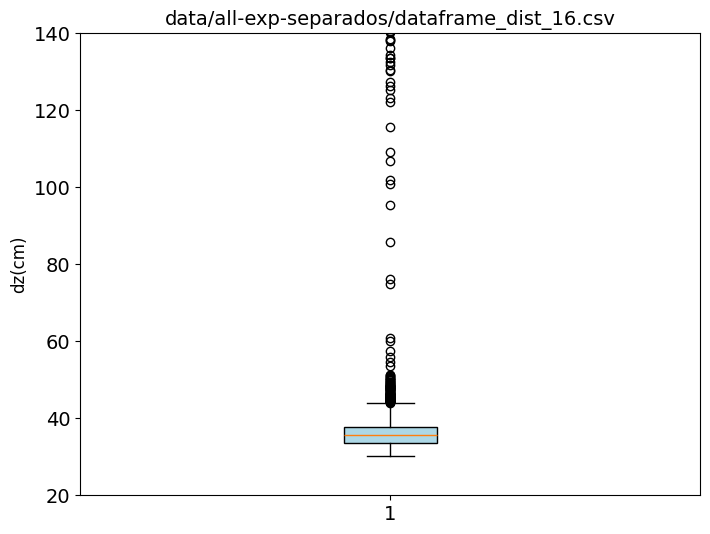

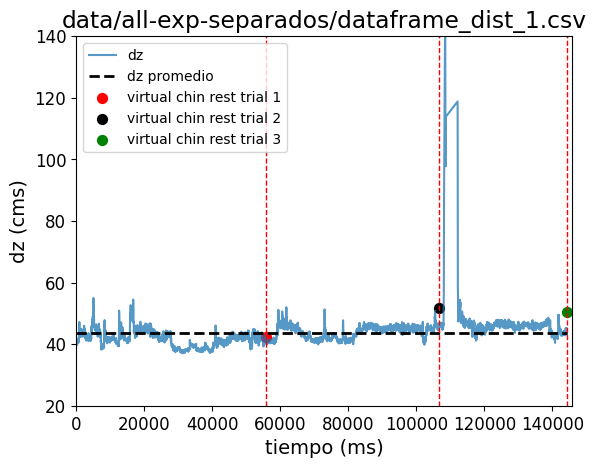

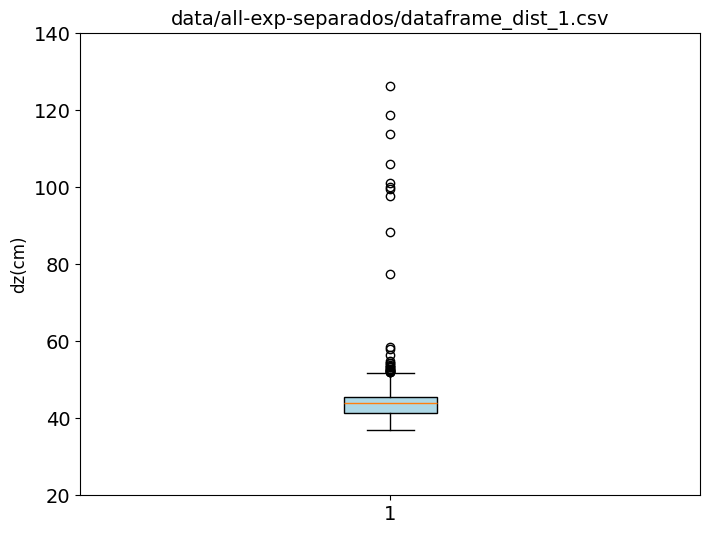

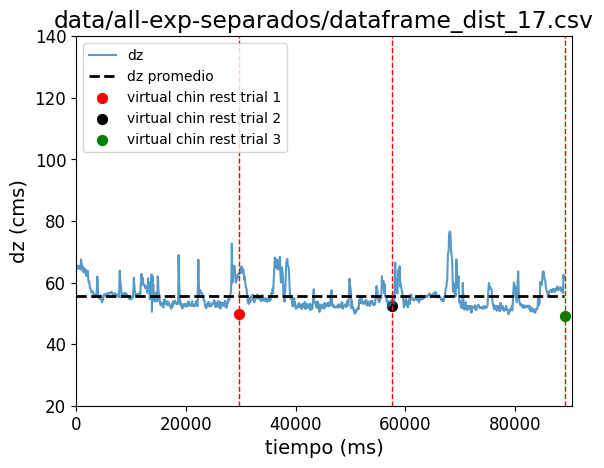

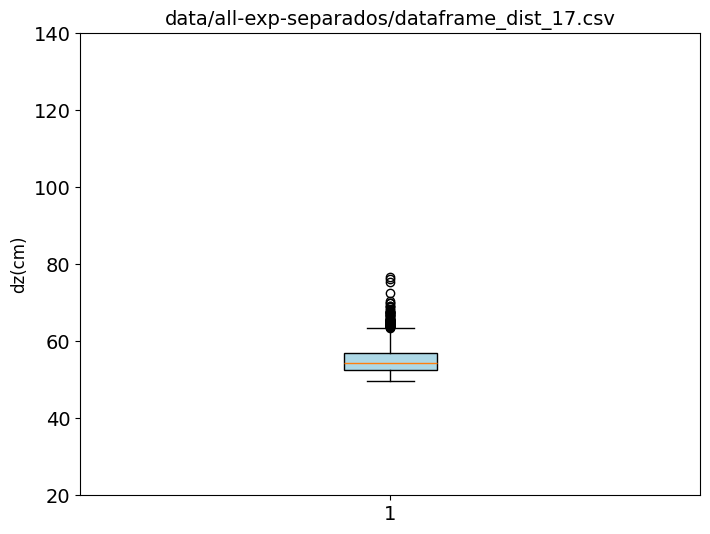

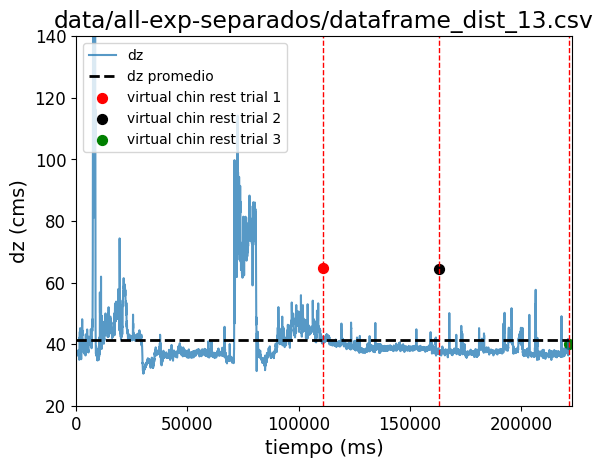

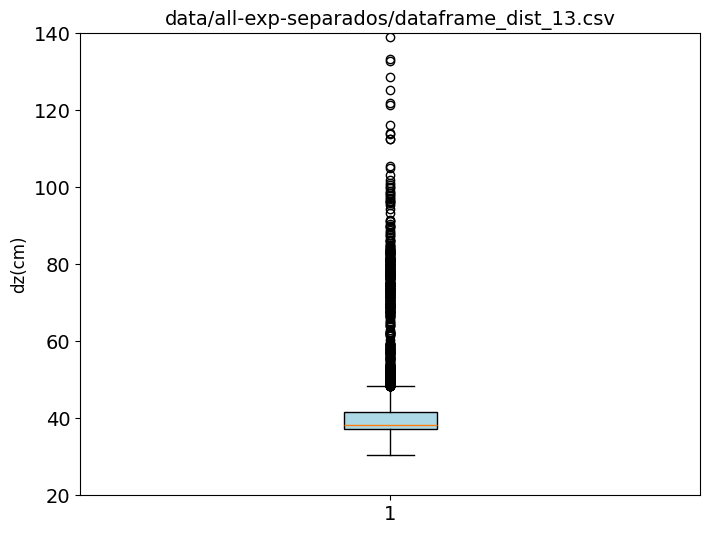

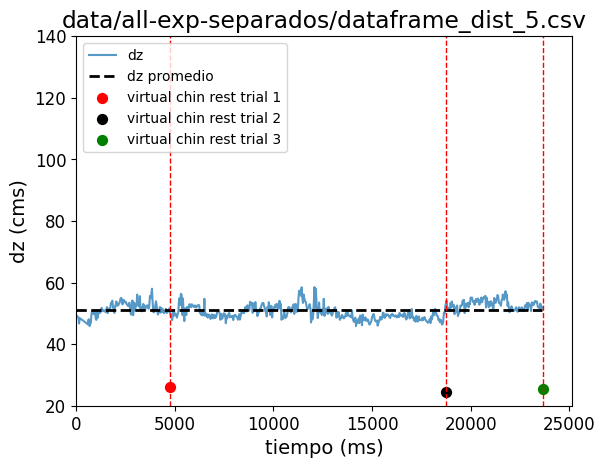

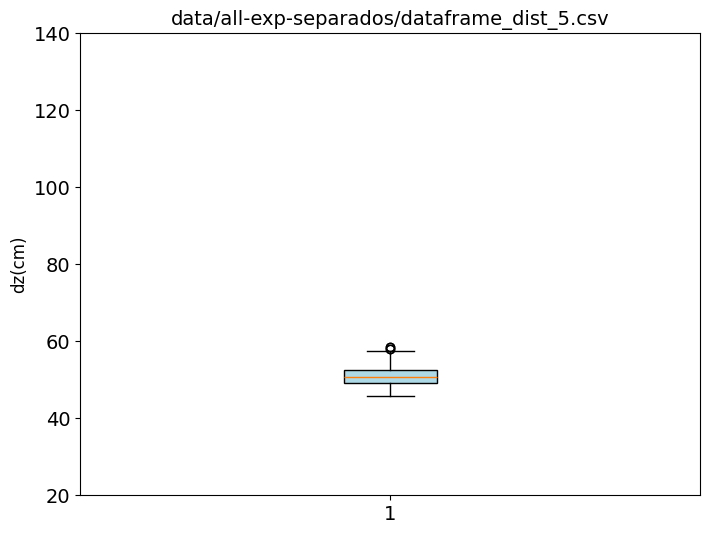

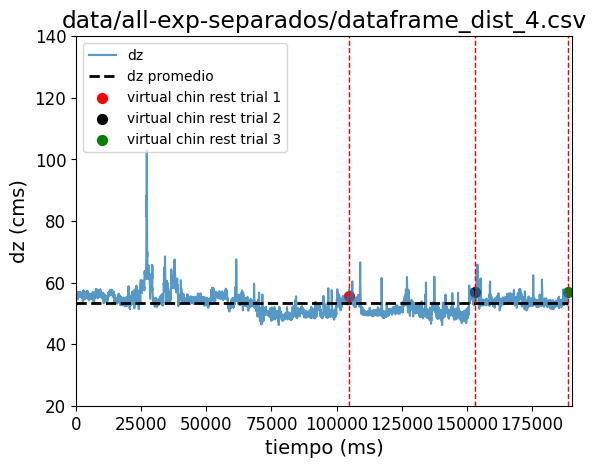

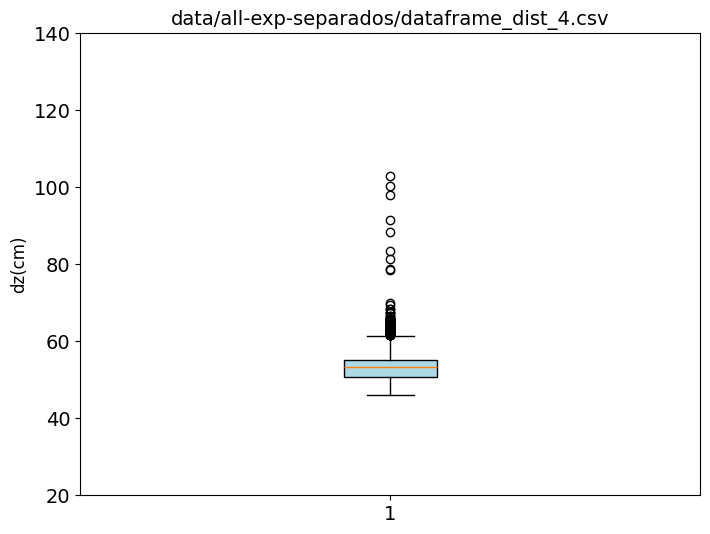

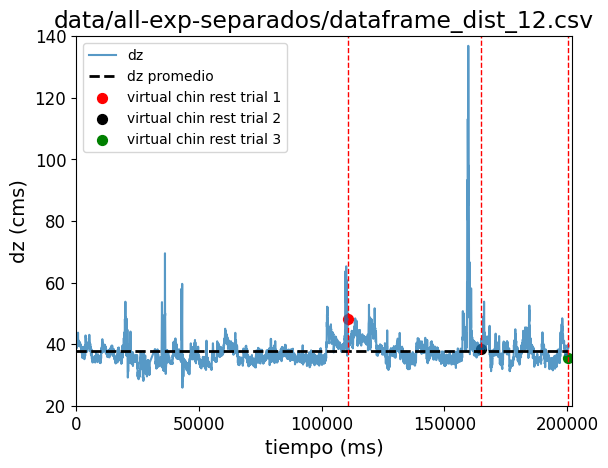

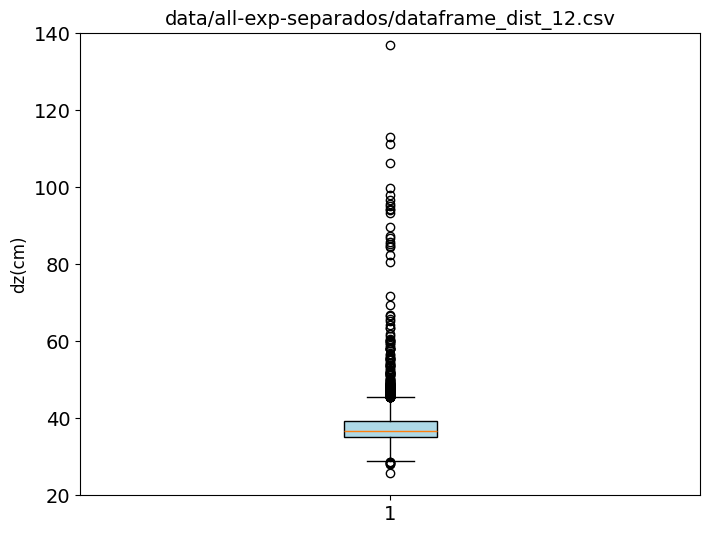

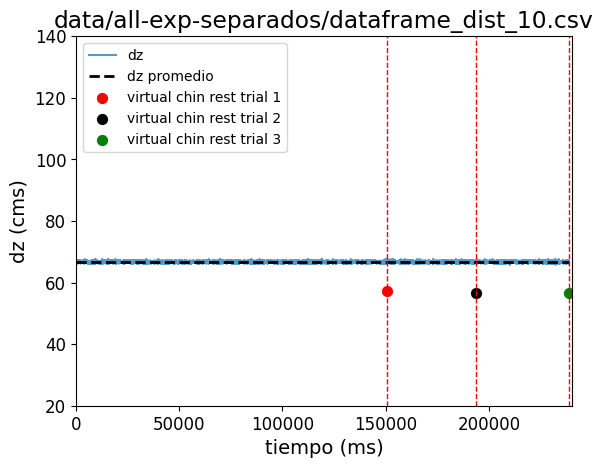

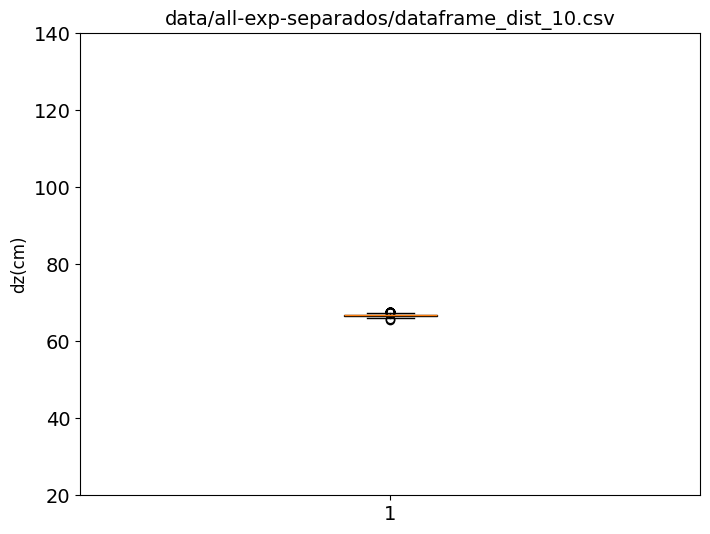

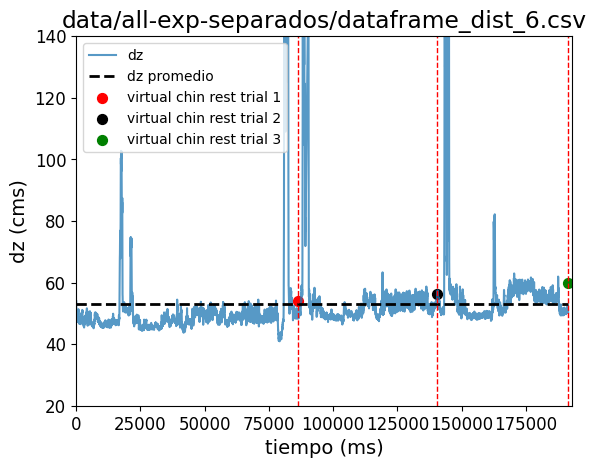

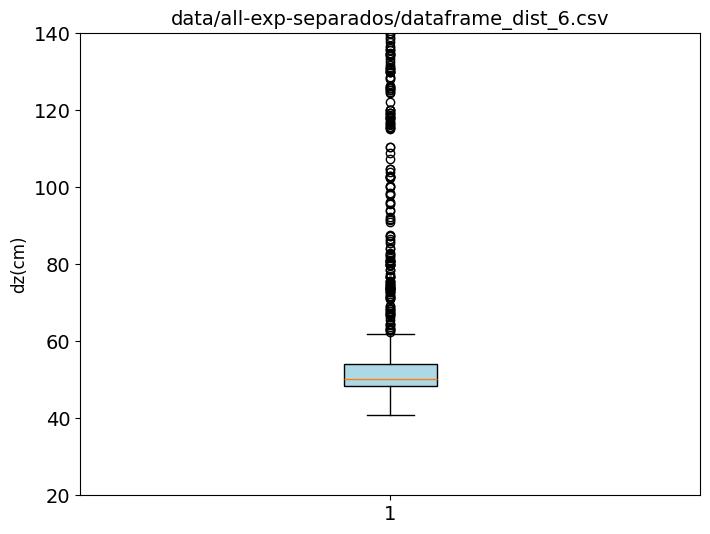

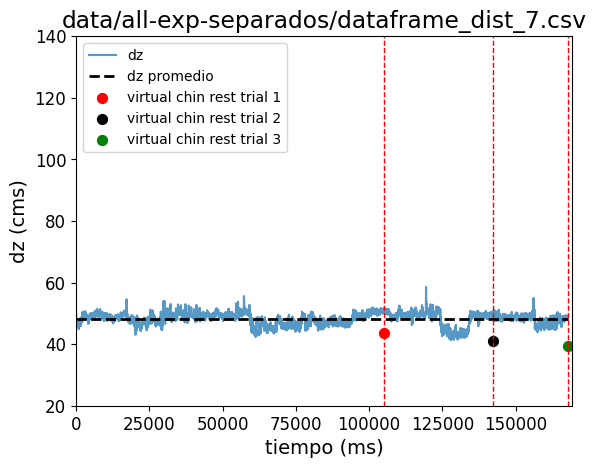

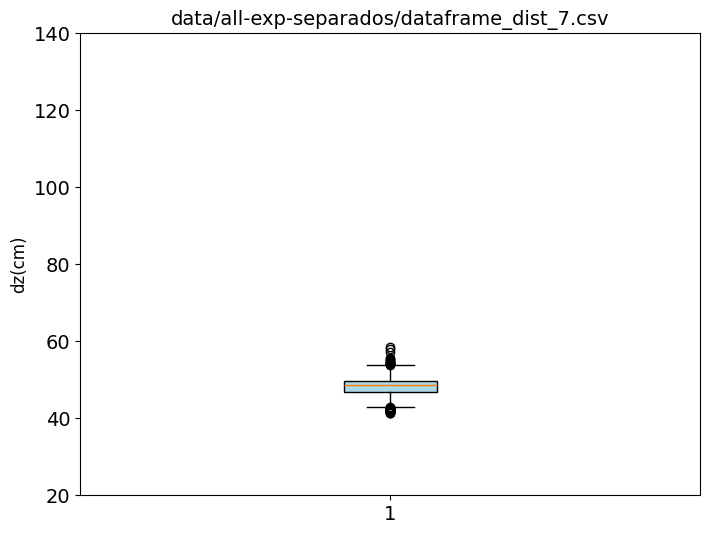

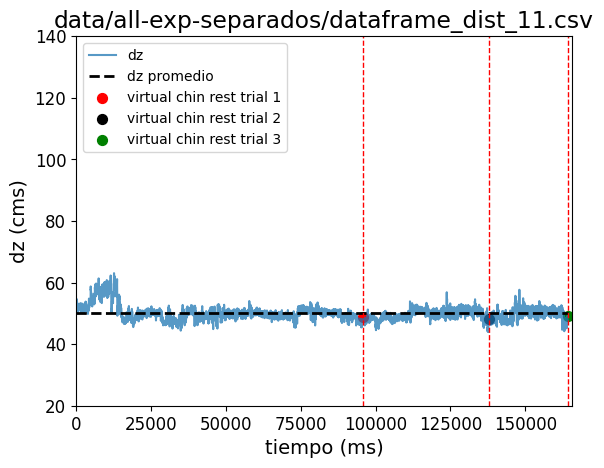

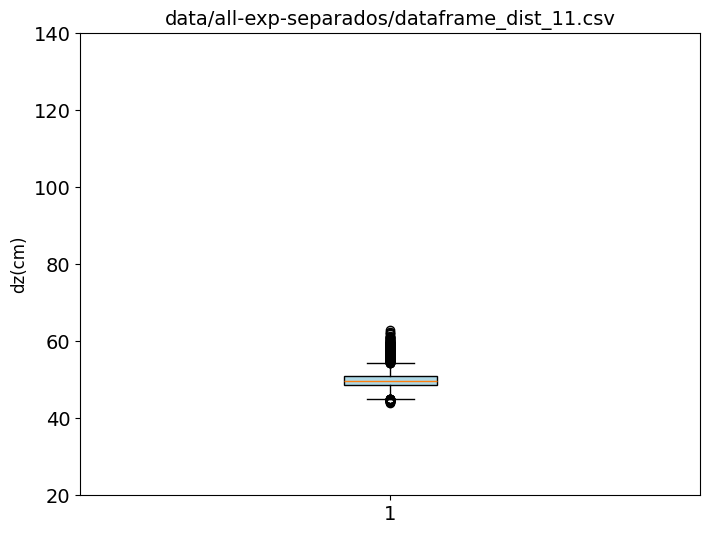

In [66]:
files = Path("./data/all-exp-separados").glob("*.csv")

for file in files:
  if "_8" not in str(file):
    if "dist" in str(file):
        df = pd.read_csv(file)
        df_webgazer = generate_webgazer_dataframe(df)

        df_virtual_chin = df[~df["view_dist_mm"].isna()].copy()
        df_virtual_chin.loc[:, ["view_dist_centimeters"]] = (
            df[~df["view_dist_mm"].isna()]["view_dist_mm"] / 10
        )
        (
            df_virtual_chin["rt"].reset_index(drop=True),
            df_webgazer.groupby("trial")["t"].max(),
        )

        df_virtual_chin['t'] = (
            df_virtual_chin['rt'] + 
            df_virtual_chin['rt'].cumsum().shift(1).fillna(0)
        )
        max_por_trial = df_webgazer.groupby('trial')['t'].max()
        max_acumulado_anterior = max_por_trial.cumsum().shift(1)
        df_webgazer['t'] = df_webgazer['t'] + df_webgazer['trial'].map(max_acumulado_anterior).fillna(0)
        df_webgazer = df_webgazer.astype({"dz": float, "t": float})
        df_webgazer.plot(x="t", y="dz", alpha=0.75, fontsize=12)
        plt.xlabel("tiempo (ms)")
        plt.ylabel("dz (cms)")
        plt.xlim(0, df_webgazer["t"].max() + 1500)
        plt.hlines(
            df_webgazer["dz"].mean(),
            df_webgazer["t"].min(),
            df_webgazer["t"].max(),
            color="k",
            linestyle="--",
            lw=2,
            label="dz promedio",
        )
        colors = ["r", "k", "g"]
        for i, (virtual_chin_time, virtual_chin_distance) in enumerate(
            zip(df_virtual_chin["t"], df_virtual_chin["view_dist_centimeters"])
        ):
            plt.axvline(virtual_chin_time, color="red", linestyle="--", lw=1)
            plt.scatter(
                virtual_chin_time,
                virtual_chin_distance,
                s=50,
                color=colors[i],
                label=f"virtual chin rest trial {i + 1}",
            )
            #plt.ylim(
              #  min(df_webgazer["dz"].min(), virtual_chin_distance) - 10,
             #   max(virtual_chin_distance, df_webgazer["dz"].max()) + 10,
            #)
            plt.ylim(
                20,
                140,
            )

        #plt.title(file)
        plt.title(file)
        plt.rcParams['font.size'] = 14
        plt.legend(loc="upper left", fontsize=10)
        plt.show()

        plt.figure(figsize=(8, 6))
        box_plot = plt.boxplot(df_webgazer["dz"].dropna(), patch_artist=True)

      # Personalizar colores
        box_plot['boxes'][0].set_facecolor('lightblue')
        box_plot['boxes'][0].set_alpha(1)
        box_plot['boxes'][0]

        plt.ylim(
            20,
            140,
        )
        
        plt.title(file, fontsize=14)
        plt.xlabel("", fontsize=12)
        plt.ylabel("dz(cm)", fontsize=12)
        plt.show()


In [12]:
df_virtual_chin.head()

,load_time,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_start_time,success,item_width_mm,item_height_mm,item_width_px,...,view_dist_mm,rt,item_width_deg,px2deg,win_width_deg,win_height_deg,webgazer_data,webgazer_targets,events,view_dist_centimeters
3,NaN,virtual-chinrest,3,127204,0.0-3.0,NaN,NaN,85.6,53.98,422.0,...,557.20,79933.0,8.784829,48.037359,29.976669,18.735418,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,55.720
4,NaN,virtual-chinrest,4,169054,0.0-4.0,NaN,NaN,85.6,53.98,422.0,...,532.64,41851.0,9.188201,45.928467,31.353104,19.595690,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,53.264
5,NaN,virtual-chinrest,5,207412,0.0-5.0,NaN,NaN,85.6,53.98,419.0,...,536.57,38358.0,9.121189,45.936993,31.347285,19.592053,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,53.657
3,NaN,virtual-chinrest,3,311704,0.0-3.0,NaN,NaN,85.6,53.98,408.0,...,491.69,142251.0,9.949739,41.006099,35.116727,21.947954,"[{""x"":0,""y"":0,""t"":5,""importantKeypoints"":{""nos...",{},NaN,49.169
4,NaN,virtual-chinrest,4,357837,0.0-4.0,NaN,NaN,85.6,53.98,416.0,...,468.84,46133.0,10.432050,39.877111,36.110941,22.569338,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,46.884


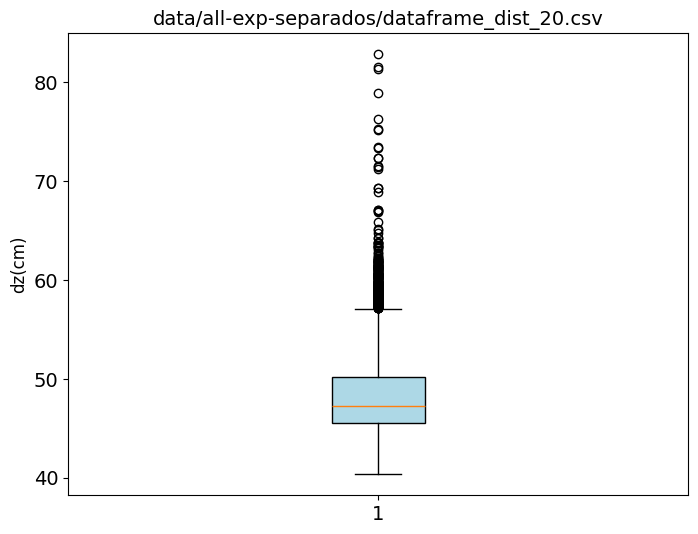

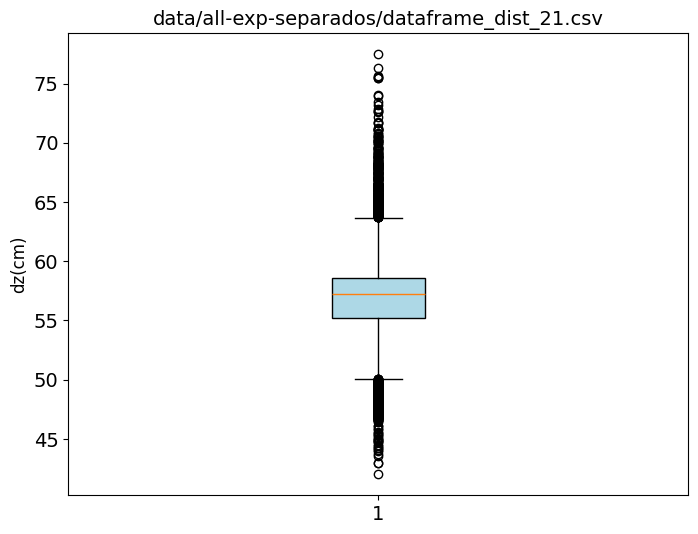

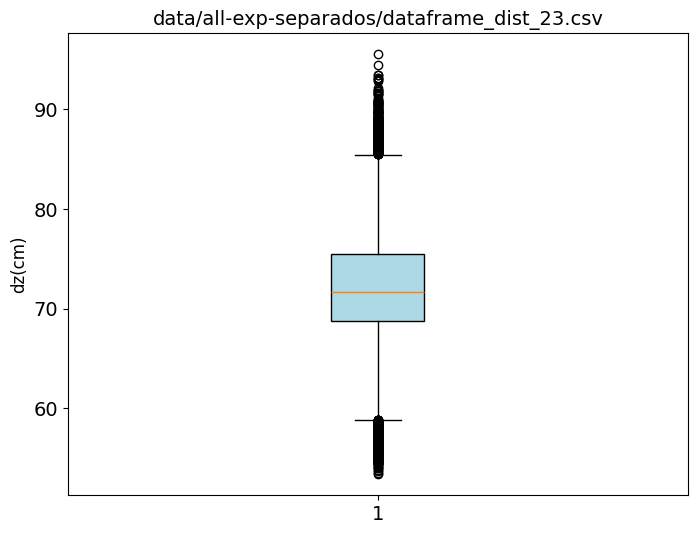

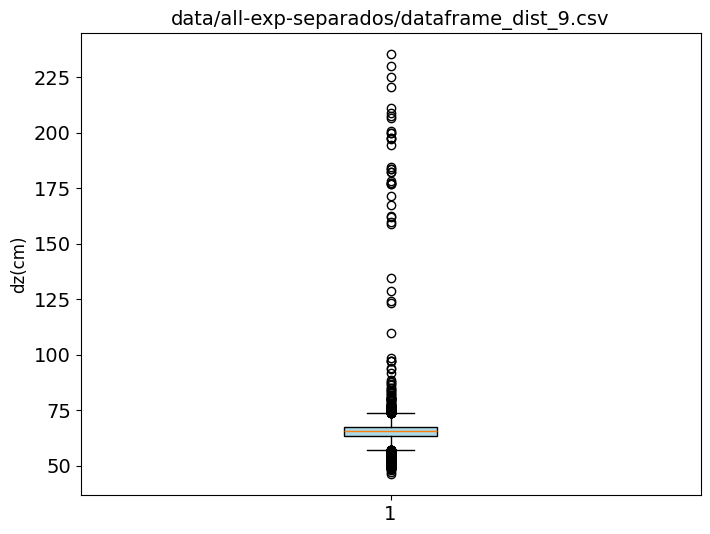

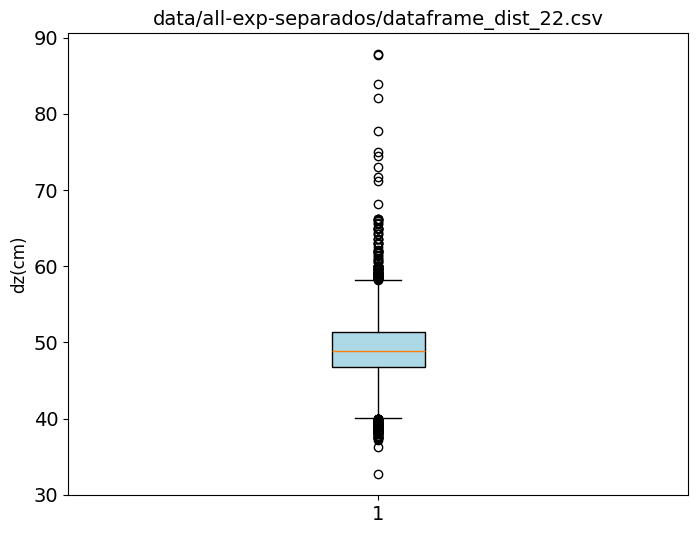

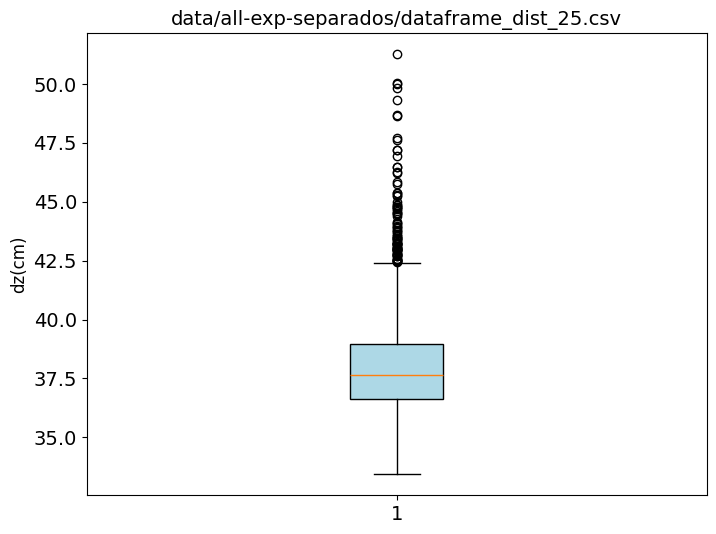

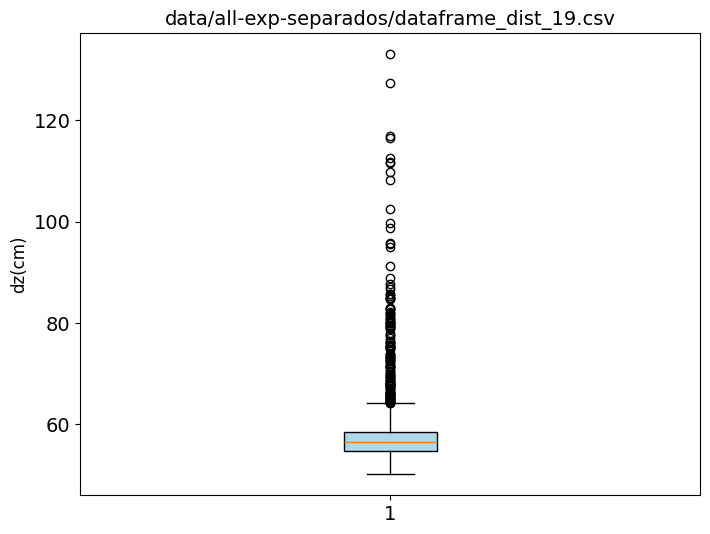

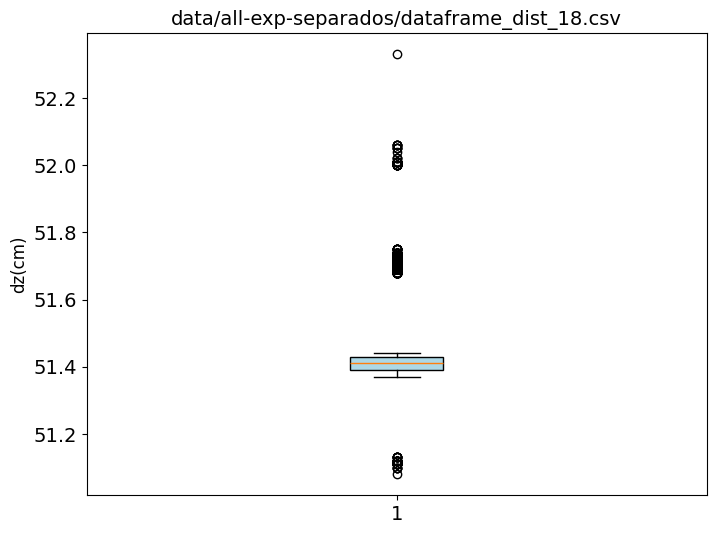

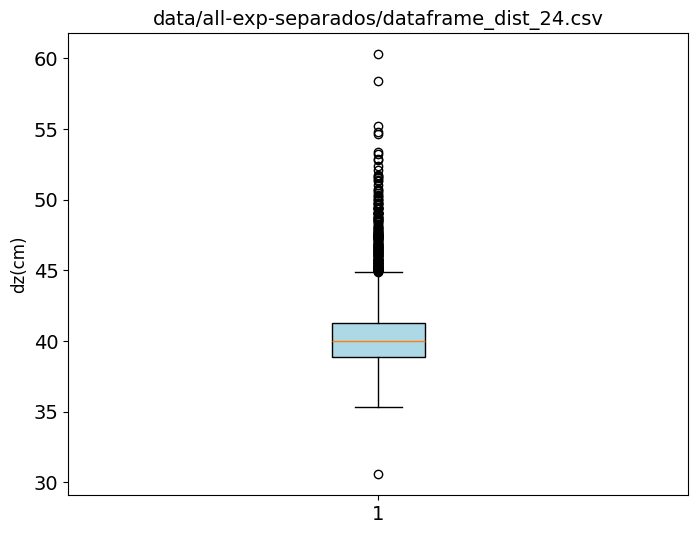

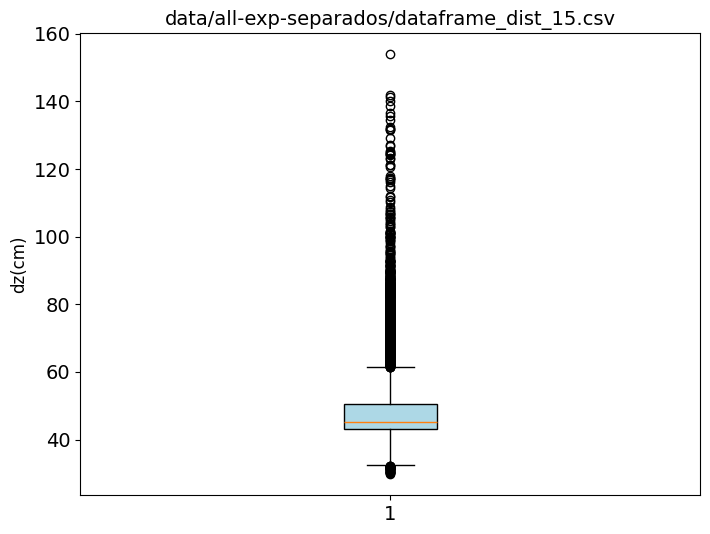

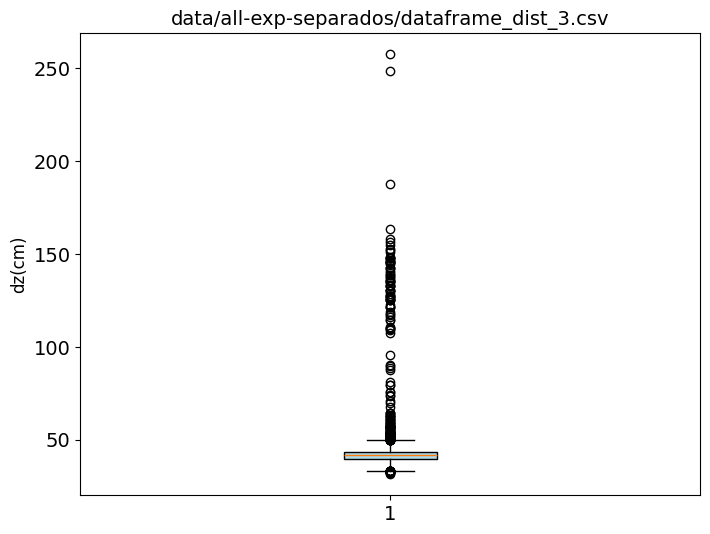

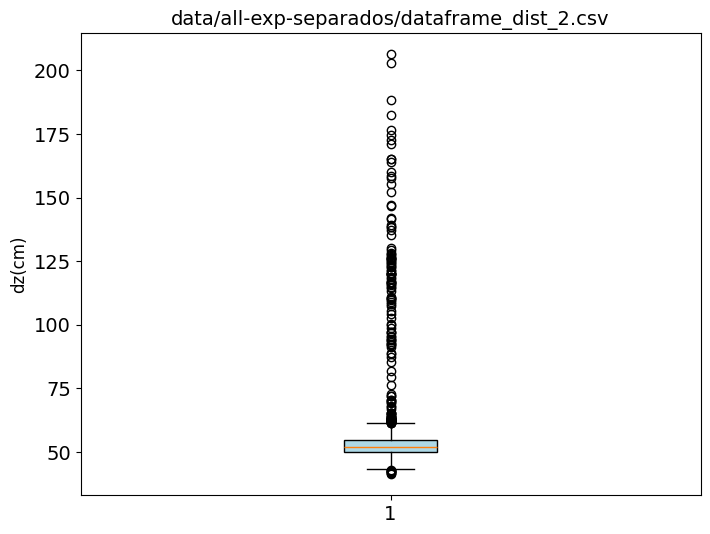

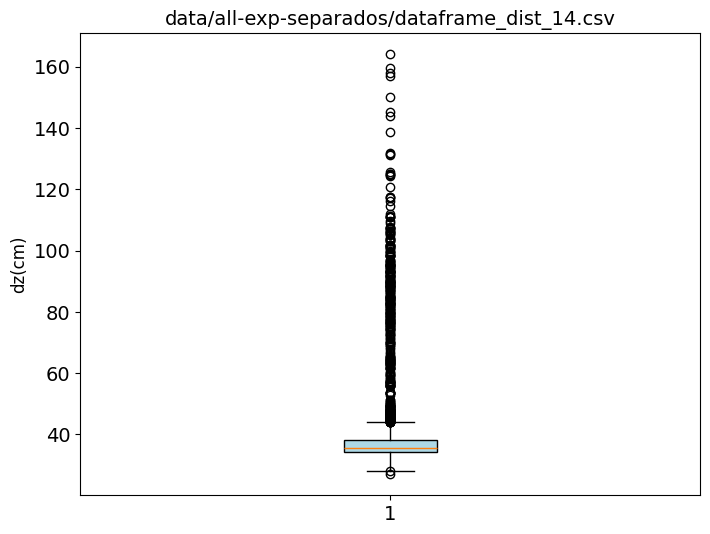

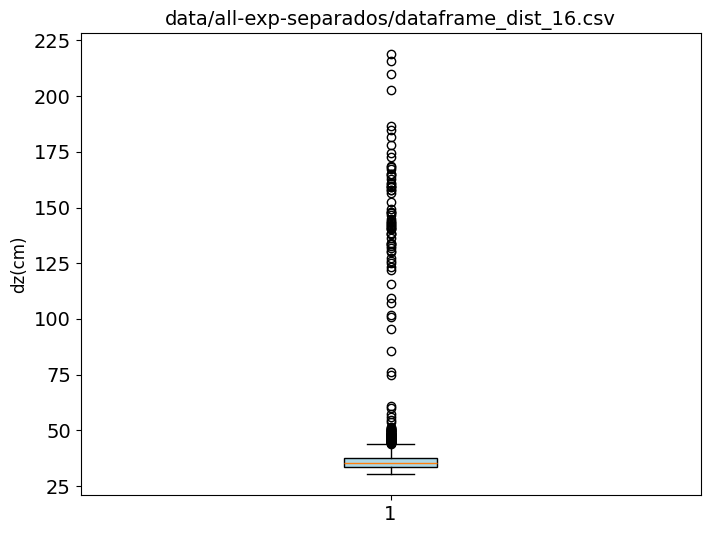

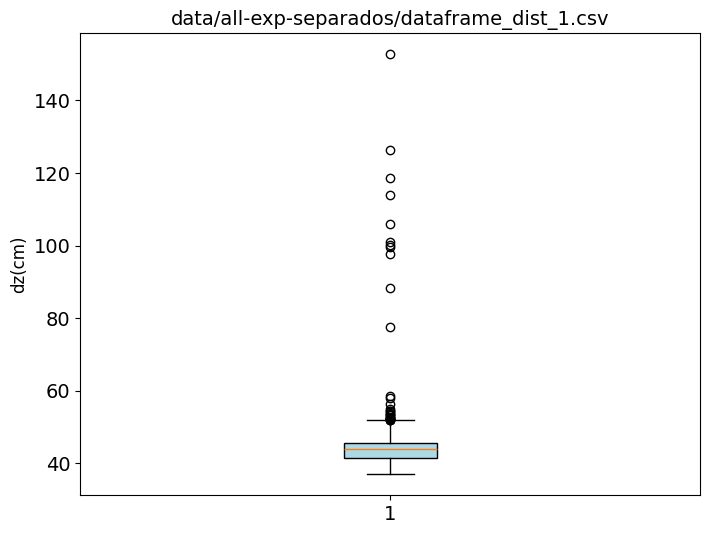

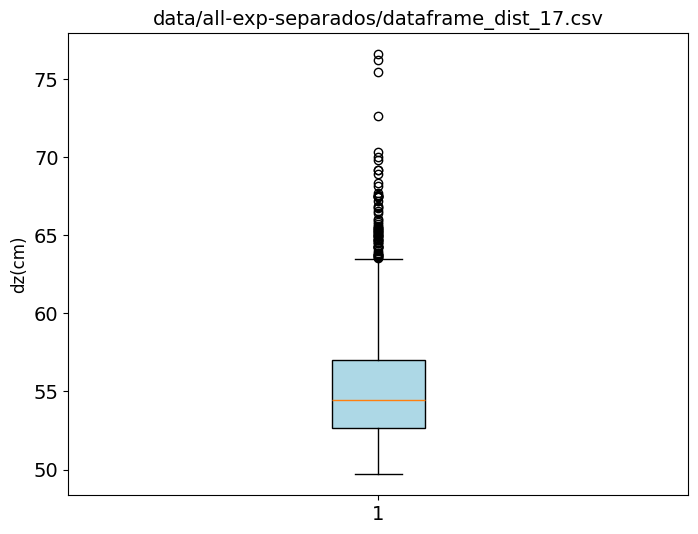

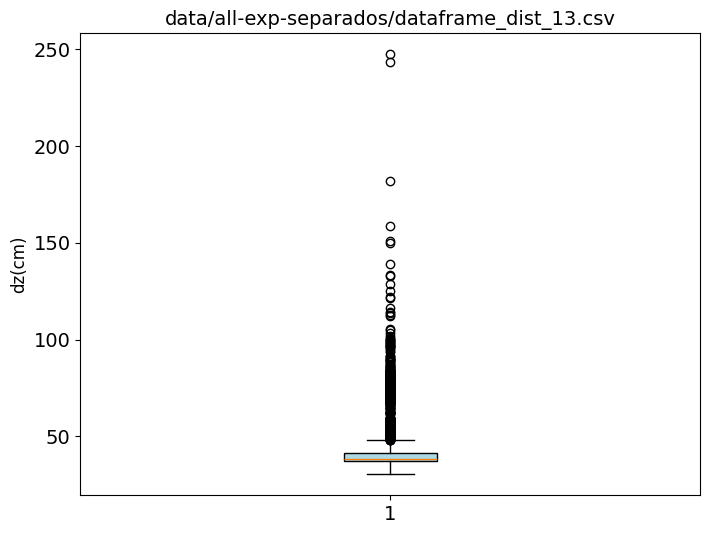

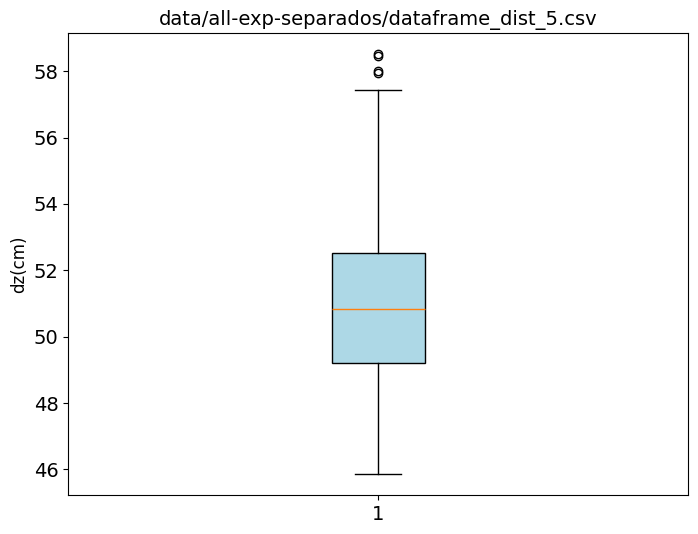

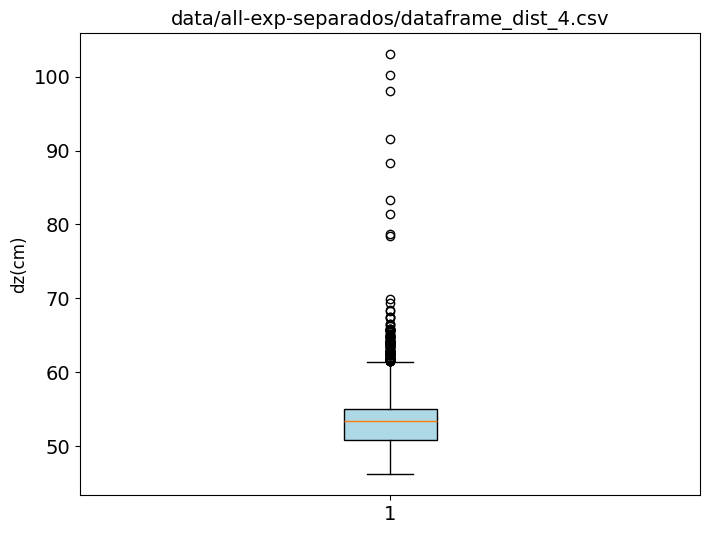

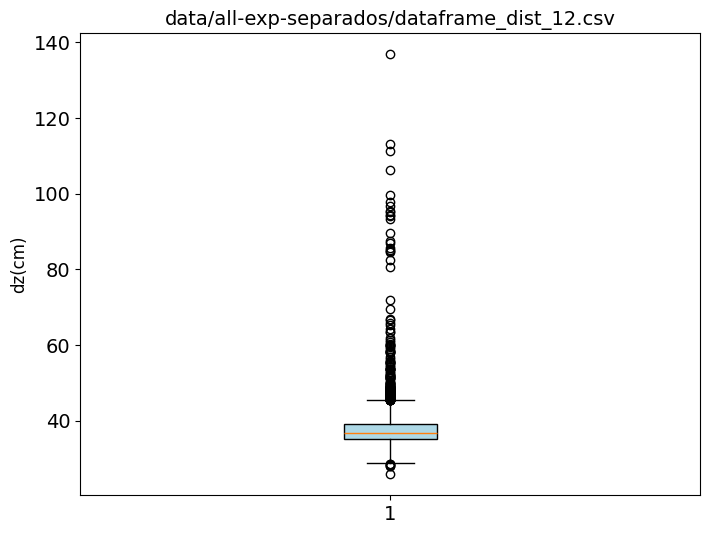

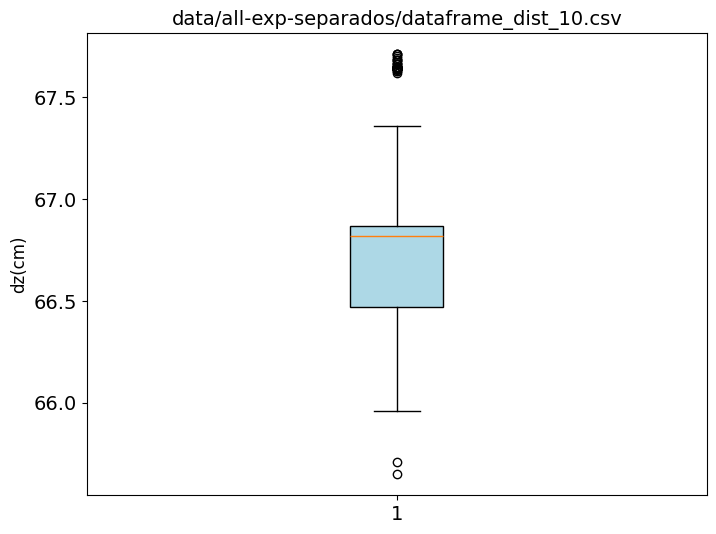

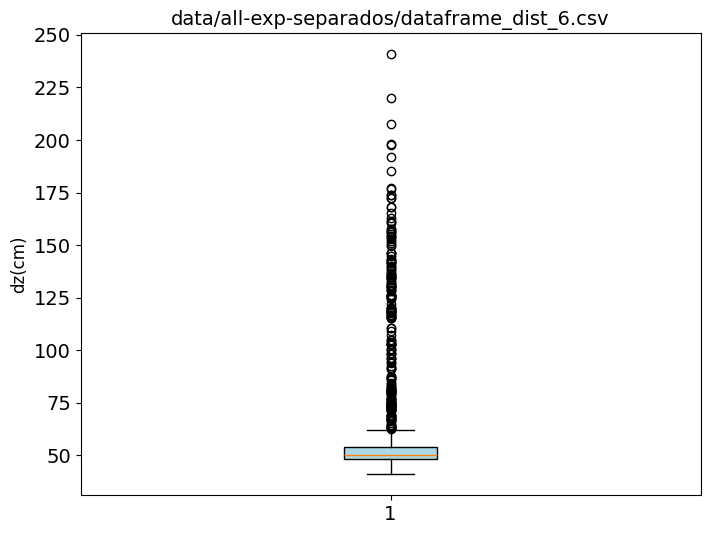

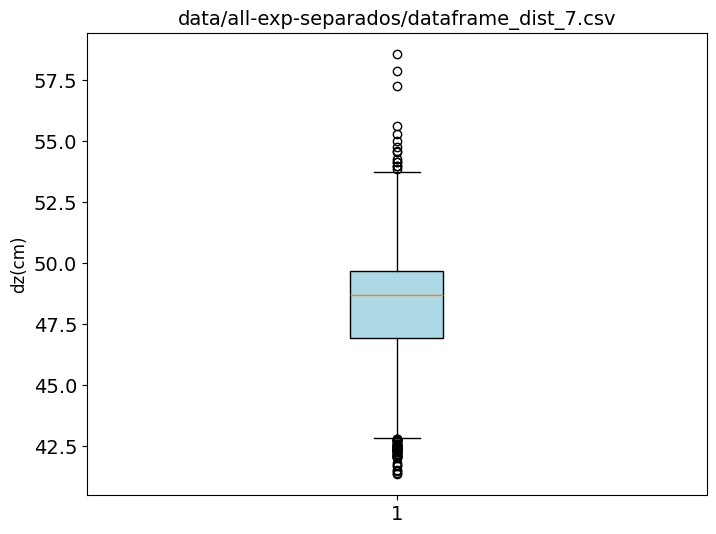

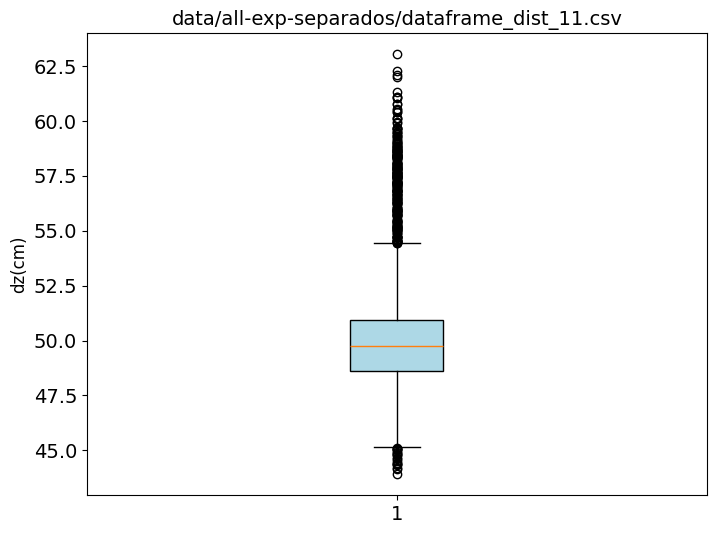

In [65]:
files = Path("./data/all-exp-separados").glob("*.csv")

for file in files:
  if "_8" not in str(file):
    if "dist" in str(file):
        df = pd.read_csv(file)
        df_webgazer = generate_webgazer_dataframe(df)

        max_por_trial = df_webgazer.groupby('trial')['t'].max()
        max_acumulado_anterior = max_por_trial.cumsum().shift(1)
        df_webgazer['t'] = df_webgazer['t'] + df_webgazer['trial'].map(max_acumulado_anterior).fillna(0)
        df_webgazer = df_webgazer.astype({"dz": float, "t": float})

        plt.figure(figsize=(8, 6))
        box_plot = plt.boxplot(df_webgazer["dz"].dropna(), patch_artist=True)

      # Personalizar colores
        box_plot['boxes'][0].set_facecolor('lightblue')
        box_plot['boxes'][0].set_alpha(1)
        box_plot['boxes'][0]

        plt.ylim(
            20,
            140,
        )
        
        plt.title(file, fontsize=14)
        plt.xlabel("", fontsize=12)
        plt.ylabel("dz(cm)", fontsize=12)
        plt.show()
